# Tutorial 02 (part 1): Deep convolutional neural networks in Tensorflow
By Prof Ivan Olier

## Introduction
The aim with this tutorial is to practise how to implement deep convolutional neural networks (CNNs) in Keras, and how to apply them to *Image Analysis*. It works significantly faster if you can use GPUs instead of CPUs.

As in previous tutorial, we should import the required packages first. We don't need to import everything from the beginning, but it is good practice to do it so.


In [1]:
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline

## Dataset
We will use the *MNIST* dataset as previous tutorial. However, in this occassion the images won't be flattened prior to be used in the network, but they will be inputed as they are (images or arrays).
* Download the MNIST dataset from Keras as before:

In [2]:
from tensorflow.keras.datasets import mnist
(X_train_img, y_train_img), (X_test_img, y_test_img) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


* Let's check data dimensions as we will need them to build the network:

In [3]:
print('X_train_img dimensions: ', X_train_img.shape)
print('y_train_img dimensions: ', y_train_img.shape)
print('X_test_img dimensions: ', X_test_img.shape)
print('y_test_img dimensions: ', y_test_img.shape)

X_train_img dimensions:  (60000, 28, 28)
y_train_img dimensions:  (60000,)
X_test_img dimensions:  (10000, 28, 28)
y_test_img dimensions:  (10000,)


MNIST images are all pre-aligned (e.g. each image only contains a hand-drawn digit). In addition, the images all have the same square size of 28×28 pixels, and all are greyscale.

CNN models (2D-CNNs, more precisely) takes 4D arrays as inputs: samples, 2D image coordinates, and channels. Colour RGB images have 3 channels (Red, Green and Blue), whilst greyscale images, 1 channel only. Therefore, we must reshape the data arrays to have a single channel:

In [4]:
X_train = X_train_img.reshape((X_train_img.shape[0], 28, 28, 1))
X_test = X_test_img.reshape((X_test_img.shape[0], 28, 28, 1))
print('X_train dimensions: ', X_train.shape)
print('X_test dimensions: ', X_test.shape)

X_train dimensions:  (60000, 28, 28, 1)
X_test dimensions:  (10000, 28, 28, 1)


Classes in `y_train` and `y_test` are represented as unique integers: $0\ldots9$. We can, therefore, use a one hot encoding for the class element of each sample, transforming the integer into a 10 element binary vector with a 1 for the index of the class value, and 0 values for all other classes. We can achieve this with the `to_categorical()` utility function:

In [5]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train_img)
y_test = to_categorical(y_test_img)
y_train[0:5,]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

Now, we should proceed with the data normalisation. As we know pixel values should go from 0 to 255, sacaling the data requires dividing the arrays by 255. The data values are integers, therfore we must convert to reals first.

In [6]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

## Building the model

Now, we will build three CNN models and see how their performances are affected:

In [45]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten

In [8]:
model1 = Sequential()
model1.add(Input(shape=(28,28,1)))
model1.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model1.add(MaxPool2D((2,2)))
model1.add(Flatten())
model1.add(Dense(512, activation='relu'))
model1.add(Dense(10, activation='softmax'))
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,769,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,774,858 (10.59 MB)

 Trainable params: 2,774,858 (10.59 MB)

 Non-trainable params: 0 (0.00 B)

We design the compiler similarly to prior models.

In [9]:
model1.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

Now, we have an architecture ready for training. THerefore, we can proceed with training the model:

In [10]:
history = model1.fit(X_train, y_train,
          batch_size=128, epochs=50,
          verbose=2,
          validation_split=0.2)

Epoch 1/50
375/375 - 8s - 20ms/step - accuracy: 0.9446 - loss: 0.1888 - val_accuracy: 0.9775 - val_loss: 0.0763
Epoch 2/50
375/375 - 3s - 7ms/step - accuracy: 0.9827 - loss: 0.0572 - val_accuracy: 0.9840 - val_loss: 0.0559
Epoch 3/50
375/375 - 3s - 8ms/step - accuracy: 0.9890 - loss: 0.0356 - val_accuracy: 0.9850 - val_loss: 0.0513
Epoch 4/50
375/375 - 3s - 7ms/step - accuracy: 0.9931 - loss: 0.0231 - val_accuracy: 0.9852 - val_loss: 0.0498
Epoch 5/50
375/375 - 2s - 6ms/step - accuracy: 0.9954 - loss: 0.0153 - val_accuracy: 0.9861 - val_loss: 0.0478
Epoch 6/50
375/375 - 2s - 7ms/step - accuracy: 0.9976 - loss: 0.0087 - val_accuracy: 0.9862 - val_loss: 0.0480
Epoch 7/50
375/375 - 3s - 7ms/step - accuracy: 0.9979 - loss: 0.0073 - val_accuracy: 0.9871 - val_loss: 0.0505
Epoch 8/50
375/375 - 5s - 13ms/step - accuracy: 0.9987 - loss: 0.0050 - val_accuracy: 0.9860 - val_loss: 0.0563
Epoch 9/50
375/375 - 3s - 7ms/step - accuracy: 0.9988 - loss: 0.0045 - val_accuracy: 0.9840 - val_loss: 0.0652

As before, we can implement a quick function to plot learning curves:

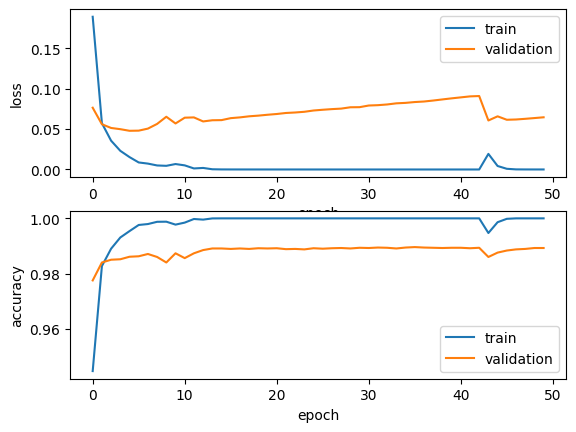

In [11]:
def plot_history(history):
    plt.figure()
    plt.subplot(2,1,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'])
    plt.subplot(2,1,2)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'])
    return;

plot_history(history)

## Predicting new cases

Let's pick few cases from the test subset to see how our new model is performing.

In [12]:
preds_prob = model1.predict(X_test[0:100,:,:,:])
preds_class = np.argmax(preds_prob, axis=1)
preds_class

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step


array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 5, 4, 9, 6,
       6, 5, 4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2,
       3, 5, 1, 2, 4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3, 7, 4,
       6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3,
       6, 1, 3, 6, 9, 3, 1, 4, 1, 7, 6, 9])

We can visualise the results too:

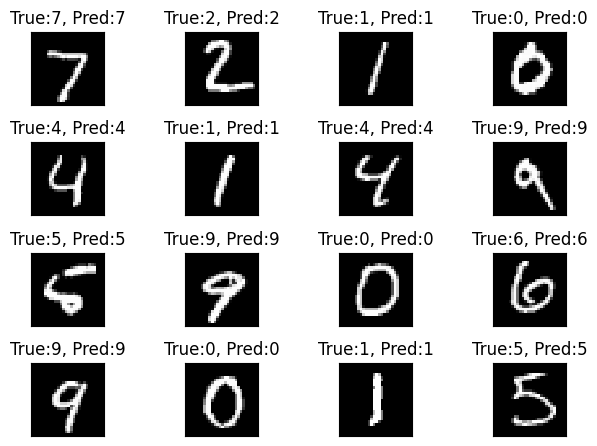

In [13]:
plt.figure(facecolor='w')
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.tight_layout()
  plt.imshow(X_test_img[i], cmap='gray', interpolation='none')
  plt.title("True:{}, Pred:{}".format(y_test_img[i],preds_class[i]))
  plt.xticks([])
  plt.yticks([])

## Model performance
Model performance is estimated similarly to prior models:

In [14]:
test_scores_model1 = model1.evaluate(X_test, y_test, verbose=0)
print("Test loss model 1:", test_scores_model1[0])
print("Test accuracy model 1:", test_scores_model1[1])
train_scores_model1 = model1.evaluate(X_train, y_train, verbose=0)
print("Train loss model 1:", train_scores_model1[0])
print("Train accuracy model 1:", train_scores_model1[1])

Test loss model 1: 0.04856133833527565
Test accuracy model 1: 0.9897000193595886
Train loss model 1: 0.012920415960252285
Train accuracy model 1: 0.9978500008583069


## Model variant
We will proceed with implementing a variant of the above model. It will contain further convolutional + max-pooling layers and remove the hidden dense layer.

In [15]:
model1 = Sequential()
model1.add(Input(shape=(28,28,1)))
model1.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model1.add(MaxPool2D((2,2)))
model1.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model1.add(MaxPool2D((2,2)))
model1.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model1.add(MaxPool2D((2,2)))
model1.add(Flatten())
model1.add(Dense(10, activation='softmax'))
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,146 (74.79 KB)

 Trainable params: 19,146 (74.79 KB)

 Non-trainable params: 0 (0.00 B)

* Is this model more or less complex than the previous one? why?
* Let's plot the model architecture (remember that plotting the architecture is only feasible for relatively small deep learning models)

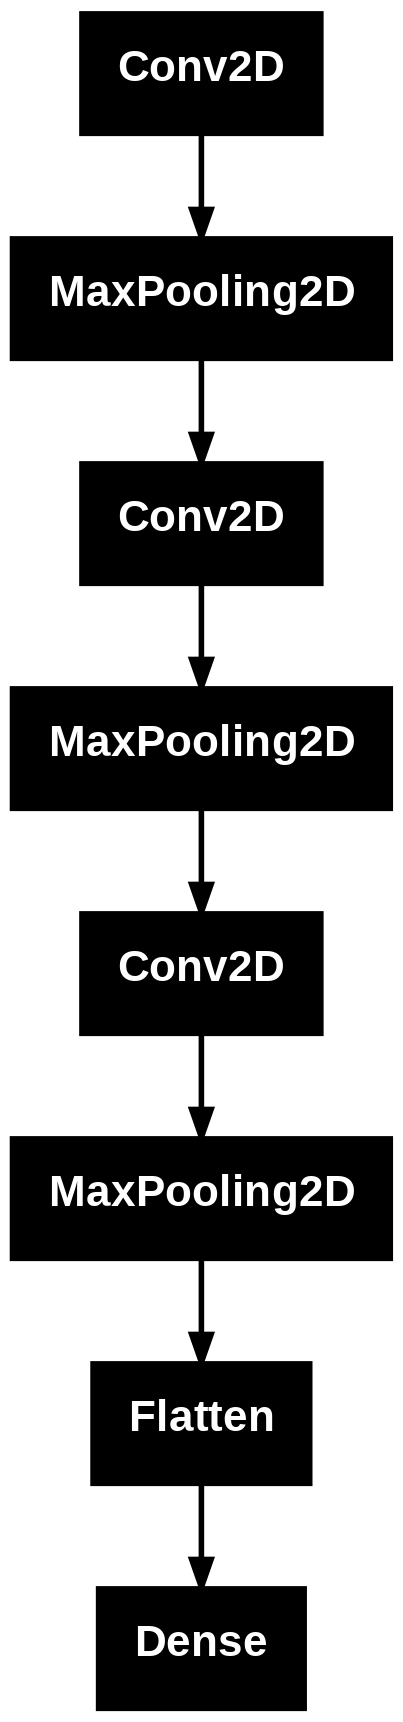

In [16]:
from tensorflow.keras.utils import plot_model
plot_model(model1)

* Now, we can compile and train the model as before.

In [18]:
model1.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

* Before we train the model, we can find useful to save the initial weights so they can be reuse later on.
* We use `get_weights` and `set_weights` functions to this aim.

In [19]:
initial_weights = model1.get_weights()

* Now, we are ready for training the model:

In [20]:
history = model1.fit(X_train, y_train,
          batch_size=128, epochs=50,
          verbose=2,
          validation_split=0.2)

Epoch 1/50
375/375 - 8s - 22ms/step - accuracy: 0.8233 - loss: 0.5728 - val_accuracy: 0.9446 - val_loss: 0.1854
Epoch 2/50
375/375 - 3s - 8ms/step - accuracy: 0.9510 - loss: 0.1622 - val_accuracy: 0.9594 - val_loss: 0.1330
Epoch 3/50
375/375 - 3s - 7ms/step - accuracy: 0.9656 - loss: 0.1158 - val_accuracy: 0.9692 - val_loss: 0.1032
Epoch 4/50
375/375 - 3s - 7ms/step - accuracy: 0.9709 - loss: 0.0973 - val_accuracy: 0.9708 - val_loss: 0.0992
Epoch 5/50
375/375 - 3s - 7ms/step - accuracy: 0.9746 - loss: 0.0843 - val_accuracy: 0.9730 - val_loss: 0.0926
Epoch 6/50
375/375 - 3s - 7ms/step - accuracy: 0.9775 - loss: 0.0742 - val_accuracy: 0.9742 - val_loss: 0.0890
Epoch 7/50
375/375 - 5s - 13ms/step - accuracy: 0.9785 - loss: 0.0699 - val_accuracy: 0.9743 - val_loss: 0.0890
Epoch 8/50
375/375 - 3s - 7ms/step - accuracy: 0.9806 - loss: 0.0620 - val_accuracy: 0.9790 - val_loss: 0.0741
Epoch 9/50
375/375 - 3s - 7ms/step - accuracy: 0.9819 - loss: 0.0568 - val_accuracy: 0.9810 - val_loss: 0.0681

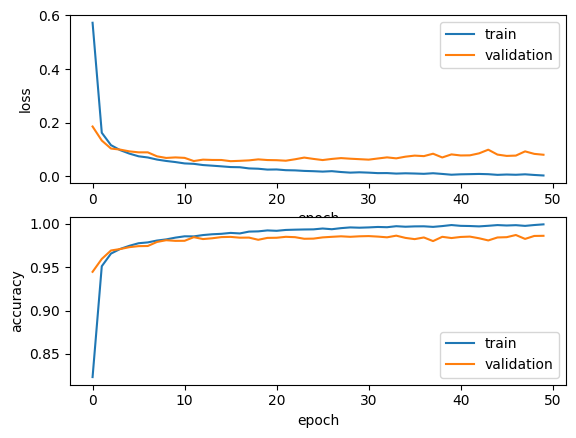

In [21]:
plot_history(history)

## Early stopping
We can implement early stopping in Tensorflow by the use of *callbacks*, which are functions that are called during training.

* For instance, the code below implements a basic `EarlyStopping` function that uses the default argument values. Please refer to the Tensorflow documentation for details about the `EarlyStopping` arguments and their meaning.

In [22]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping()

* To train the model again, we should use the initial weights we saved before. If we fail to do this, `fit` function would use the weight values from the last training iteration.
* We use `set_weights` function to reset the weights to the initial ones:

In [23]:
model1.set_weights(initial_weights)

* Now, we can train the model again but using early stopping this time.

In [24]:
history = model1.fit(X_train, y_train,
          batch_size=128, epochs=100,
          verbose=2,
          validation_split=0.2,
          callbacks=[early_stopping])

Epoch 1/100
375/375 - 3s - 7ms/step - accuracy: 0.8478 - loss: 0.4730 - val_accuracy: 0.9513 - val_loss: 0.1568
Epoch 2/100
375/375 - 5s - 13ms/step - accuracy: 0.9557 - loss: 0.1436 - val_accuracy: 0.9649 - val_loss: 0.1173
Epoch 3/100
375/375 - 3s - 8ms/step - accuracy: 0.9684 - loss: 0.1049 - val_accuracy: 0.9732 - val_loss: 0.0910
Epoch 4/100
375/375 - 3s - 8ms/step - accuracy: 0.9730 - loss: 0.0885 - val_accuracy: 0.9768 - val_loss: 0.0815
Epoch 5/100
375/375 - 3s - 8ms/step - accuracy: 0.9766 - loss: 0.0767 - val_accuracy: 0.9768 - val_loss: 0.0803
Epoch 6/100
375/375 - 3s - 7ms/step - accuracy: 0.9800 - loss: 0.0658 - val_accuracy: 0.9797 - val_loss: 0.0695
Epoch 7/100
375/375 - 2s - 6ms/step - accuracy: 0.9815 - loss: 0.0599 - val_accuracy: 0.9796 - val_loss: 0.0707


* Below, a better version of early stopping.
* Remember to reset the weights:

In [33]:
custom_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    min_delta=0.001
)

In [34]:
model1.set_weights(initial_weights)
history = model1.fit(X_train, y_train,
          batch_size=128, epochs=100,
          verbose=2,
          validation_split=0.2,
          callbacks=[custom_early_stopping])

Epoch 1/100
375/375 - 4s - 9ms/step - accuracy: 0.8099 - loss: 0.5897 - val_accuracy: 0.9485 - val_loss: 0.1725
Epoch 2/100
375/375 - 3s - 9ms/step - accuracy: 0.9561 - loss: 0.1447 - val_accuracy: 0.9632 - val_loss: 0.1211
Epoch 3/100
375/375 - 3s - 8ms/step - accuracy: 0.9684 - loss: 0.1036 - val_accuracy: 0.9682 - val_loss: 0.1047
Epoch 4/100
375/375 - 3s - 9ms/step - accuracy: 0.9739 - loss: 0.0872 - val_accuracy: 0.9730 - val_loss: 0.0895
Epoch 5/100
375/375 - 3s - 8ms/step - accuracy: 0.9773 - loss: 0.0746 - val_accuracy: 0.9787 - val_loss: 0.0765
Epoch 6/100
375/375 - 4s - 10ms/step - accuracy: 0.9796 - loss: 0.0657 - val_accuracy: 0.9783 - val_loss: 0.0733
Epoch 7/100
375/375 - 3s - 8ms/step - accuracy: 0.9809 - loss: 0.0614 - val_accuracy: 0.9797 - val_loss: 0.0664
Epoch 8/100
375/375 - 3s - 8ms/step - accuracy: 0.9833 - loss: 0.0539 - val_accuracy: 0.9800 - val_loss: 0.0704
Epoch 9/100
375/375 - 3s - 7ms/step - accuracy: 0.9850 - loss: 0.0477 - val_accuracy: 0.9758 - val_loss

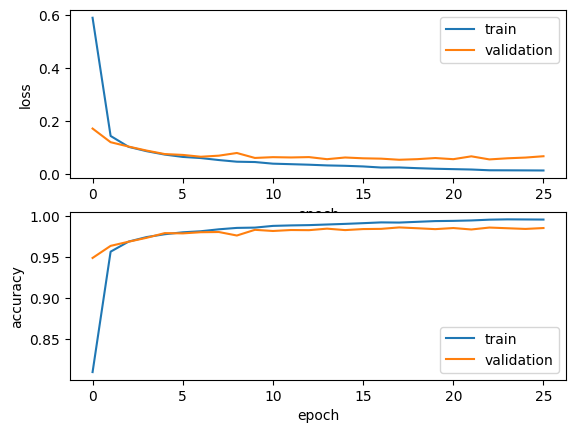

In [35]:
plot_history(history)

## Exercise
Implement two more CNN models as follows:
1. A two convolutional + max pooling layers and a one hidden dense layer model
2. Add another dense layer. Consider the use of dropout layers as a way to control for overfitting.

In [52]:
ejercicio_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    min_delta=0.001
)

In [37]:
ejercicio1 = Sequential(name="Ejercicio_1")
ejercicio1.add(Input(shape=(28,28,1)))
ejercicio1.add(Conv2D(filters=32, kernel_size=(3,3), activation='selu'))
ejercicio1.add(MaxPool2D((2,2)))
ejercicio1.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
ejercicio1.add(MaxPool2D((2,2)))
ejercicio1.add(Flatten())
ejercicio1.add(Dense(512, activation='relu'))
ejercicio1.add(Dense(10, activation='softmax'))
ejercicio1.summary()

Model: "Ejercicio_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       410,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,810 (1.62 MB)

 Trainable params: 424,810 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

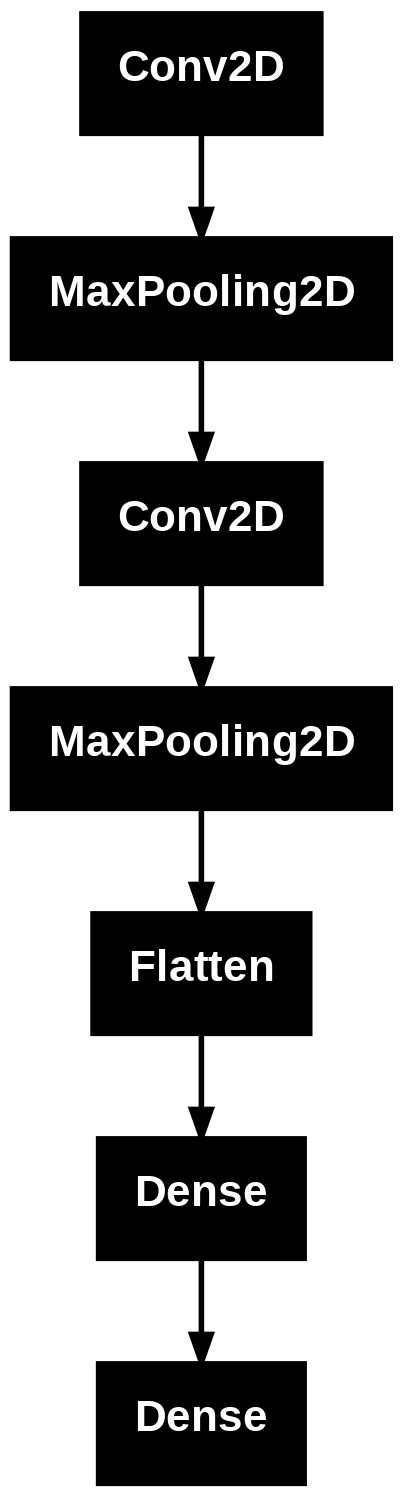

In [38]:
plot_model(ejercicio1)

In [40]:
ejercicio1.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

In [53]:
history = ejercicio1.fit(X_train, y_train,
          batch_size=128, epochs=100,
          verbose=2,
          validation_split=0.2,
          callbacks=[ejercicio_early_stopping])

Epoch 1/100
375/375 - 4s - 9ms/step - accuracy: 0.9934 - loss: 0.0208 - val_accuracy: 0.9877 - val_loss: 0.0447
Epoch 2/100
375/375 - 4s - 10ms/step - accuracy: 0.9947 - loss: 0.0165 - val_accuracy: 0.9889 - val_loss: 0.0404
Epoch 3/100
375/375 - 3s - 9ms/step - accuracy: 0.9963 - loss: 0.0111 - val_accuracy: 0.9887 - val_loss: 0.0494
Epoch 4/100
375/375 - 3s - 8ms/step - accuracy: 0.9962 - loss: 0.0111 - val_accuracy: 0.9883 - val_loss: 0.0478
Epoch 5/100
375/375 - 3s - 9ms/step - accuracy: 0.9969 - loss: 0.0091 - val_accuracy: 0.9854 - val_loss: 0.0591
Epoch 6/100
375/375 - 4s - 10ms/step - accuracy: 0.9976 - loss: 0.0072 - val_accuracy: 0.9889 - val_loss: 0.0496
Epoch 7/100
375/375 - 3s - 8ms/step - accuracy: 0.9985 - loss: 0.0047 - val_accuracy: 0.9895 - val_loss: 0.0475
Epoch 8/100
375/375 - 3s - 9ms/step - accuracy: 0.9977 - loss: 0.0065 - val_accuracy: 0.9883 - val_loss: 0.0507
Epoch 9/100
375/375 - 3s - 8ms/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.9898 - val_los

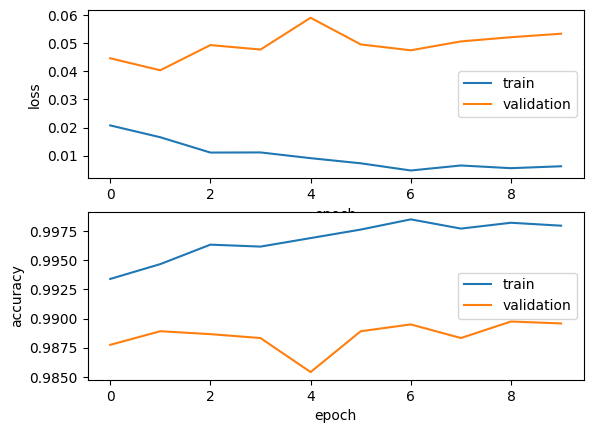

In [54]:
plot_history(history)

In [55]:
ejercicio2 = Sequential(name="Ejercicio_2")
ejercicio2.add(Input(shape=(28,28,1)))
ejercicio2.add(Conv2D(filters=32, kernel_size=(3,3), activation='selu'))
ejercicio2.add(MaxPool2D((2,2)))
ejercicio2.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
ejercicio2.add(MaxPool2D((2,2)))
ejercicio2.add(Flatten())
ejercicio2.add(Dense(512, activation='relu'))
ejercicio2.add(Dropout(rate=0.5))
ejercicio2.add(Dense(512, activation='selu'))
ejercicio2.add(Dropout(rate=0.5))
ejercicio2.add(Dense(10, activation='softmax'))
ejercicio2.summary()

Model: "Ejercicio_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       410,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687,466 (2.62 MB)

 Trainable params: 687,466 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
ejercicio2.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

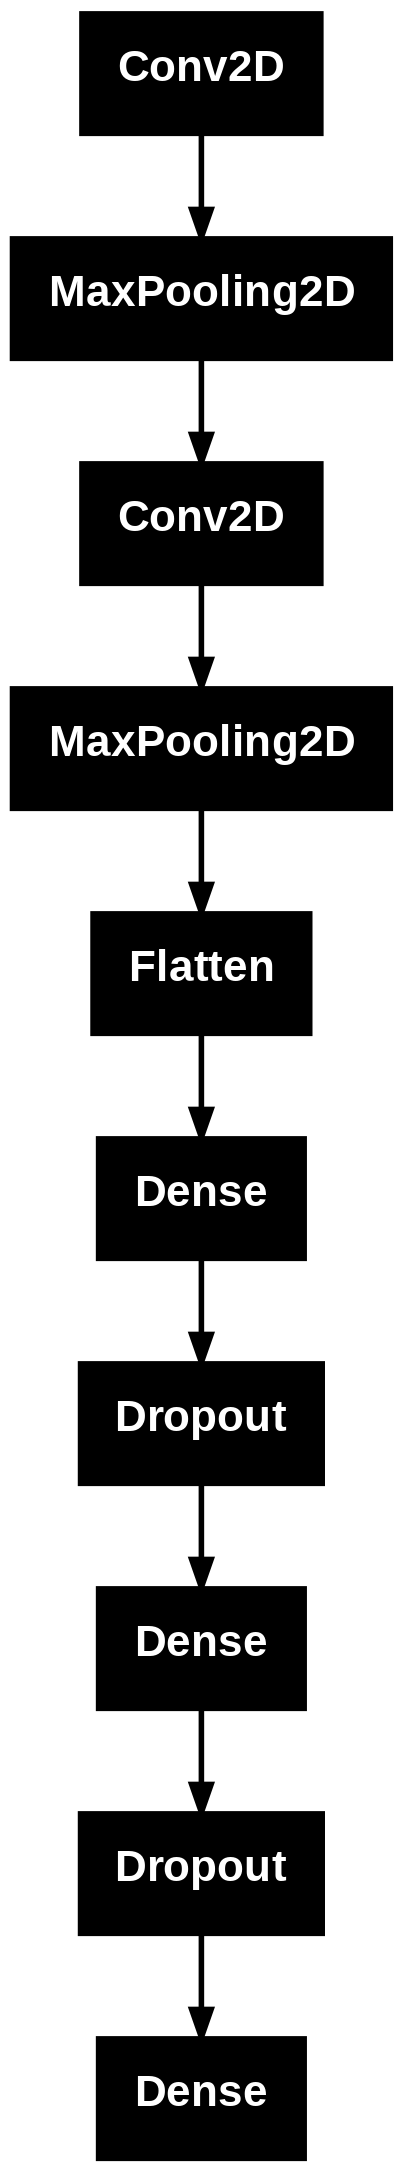

In [49]:
plot_model(ejercicio2)

Epoch 1/100
375/375 - 8s - 21ms/step - accuracy: 0.9200 - loss: 0.2527 - val_accuracy: 0.9808 - val_loss: 0.0639
Epoch 2/100
375/375 - 3s - 7ms/step - accuracy: 0.9764 - loss: 0.0767 - val_accuracy: 0.9865 - val_loss: 0.0471
Epoch 3/100
375/375 - 3s - 8ms/step - accuracy: 0.9825 - loss: 0.0553 - val_accuracy: 0.9895 - val_loss: 0.0409
Epoch 4/100
375/375 - 3s - 7ms/step - accuracy: 0.9855 - loss: 0.0460 - val_accuracy: 0.9878 - val_loss: 0.0411
Epoch 5/100
375/375 - 3s - 7ms/step - accuracy: 0.9880 - loss: 0.0374 - val_accuracy: 0.9905 - val_loss: 0.0377
Epoch 6/100
375/375 - 3s - 7ms/step - accuracy: 0.9895 - loss: 0.0338 - val_accuracy: 0.9908 - val_loss: 0.0382
Epoch 7/100
375/375 - 3s - 8ms/step - accuracy: 0.9906 - loss: 0.0299 - val_accuracy: 0.9905 - val_loss: 0.0368
Epoch 8/100
375/375 - 3s - 8ms/step - accuracy: 0.9911 - loss: 0.0272 - val_accuracy: 0.9895 - val_loss: 0.0418
Epoch 9/100
375/375 - 3s - 7ms/step - accuracy: 0.9914 - loss: 0.0267 - val_accuracy: 0.9903 - val_loss

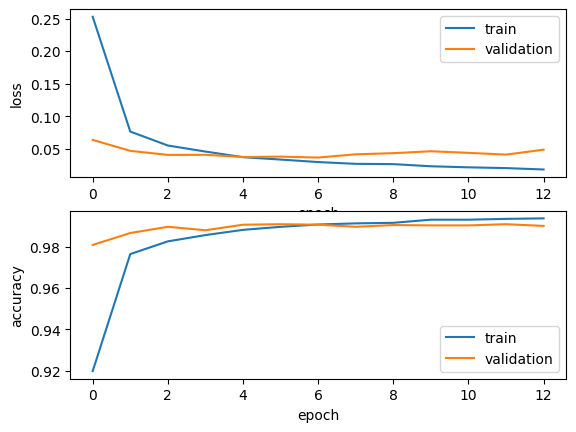

In [57]:
history = ejercicio2.fit(X_train, y_train,
          batch_size=128, epochs=100,
          verbose=2,
          validation_split=0.2,
          callbacks=[ejercicio_early_stopping])
plot_history(history)